# Занятие 11. Описательная статистика и визуализация распределений

> **Цель занятия:** научиться описывать данные числами и картинками — считать меры
> центра (**среднее, медиана, мода**) и разброса (**дисперсия, стандартное отклонение,
> квантили**), различать типы переменных, читать **форму распределения** (асимметрия и
> эксцесс), строить **гистограммы** и **KDE**, узнавать основные виды распределений
> и понимать разницу между **генеральной совокупностью** и **выборкой**.

**Что будет:**
1. **Случайные величины и типы переменных** — количественные и качественные;
2. **Меры центральной тенденции** — `mean`, `median`, `mode`: формулы и расчёт руками;
3. **Меры разброса** — дисперсия, стандартное отклонение, квантили, `IQR`;
4. **Гистограммы и KDE** — как увидеть распределение глазами;
5. **Форма распределения** — асимметрия (`skewness`) и эксцесс (`kurtosis`);
6. **Виды распределений** — нормальное, логнормальное, экспоненциальное;
7. **Генеральная совокупность и выборка** — по части судим о целом.

В каждой части будет пометка **«На практике»** — где приём реально применяют.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

rng = np.random.default_rng(42)  # фиксируем seed для воспроизводимости

## Данные для примеров — зарплаты сотрудников

Будем работать с датасетом о **1200 сотрудниках** IT-компании. У каждого есть отдел,
грейд, образование, город, опыт, а главное — **`salary`** (зарплата в рублях). Зарплата —
классический **скошенный** признак: большинство получает умеренно, но топы уходят в
длинный правый хвост. На ней удобно смотреть все меры и формы.

In [2]:
df = pd.read_csv('data/salaries.csv', sep=';')
print('Размер таблицы:', df.shape)
df.head()

Размер таблицы: (1200, 12)


,employee_id,department,grade,education,city,gender,remote,age,experience,performance,salary,bonus
0,1000,Маркетинг,Junior,Бакалавр,Москва,Ж,Нет,26,0,4,77221,11632
1,1001,Инженерия,Middle,Бакалавр,Москва,Ж,Да,33,3,5,151093,7784
2,1002,Инженерия,Senior,Магистр,Москва,М,Нет,36,7,5,326473,9410
3,1003,Инженерия,Junior,PhD,Москва,М,Да,23,0,5,124353,8475
4,1004,Финансы,Middle,Бакалавр,Москва,Ж,Нет,34,5,4,146694,32831


---
## Часть 1. Случайные величины и типы переменных

**Разведочный анализ данных** (*EDA, Exploratory Data Analysis*) начинается с вопроса к
каждому столбцу: **как в нём распределены значения** — какие часто, какие редко, где центр
и как велик разброс. Ответ и есть описательная статистика.

### 1.1. Что такое случайная величина

**Случайная величина** — величина, значение которой заранее не известно и меняется от
объекта к объекту. Зарплата случайного сотрудника, его возраст, опыт — всё это случайные
величины. Один столбец таблицы — набор **наблюдений** одной случайной величины.

**Распределение** — это то, **как часто** величина принимает разные значения. Именно его
мы описываем: числами (среднее, разброс) и картинками (гистограмма, KDE).

### 1.2. Количественные и качественные переменные

Тип переменной определяет, какие меры вообще осмысленны.

| Тип | Подтип | Что это | Примеры в наших данных |
|---|---|---|---|
| **Количественные** (числовые) | непрерывные | измеряются, могут быть дробными | `salary`, `bonus` |
| | дискретные | считаются, только целые | `age`, `experience` |
| **Качественные** (категориальные) | номинальные | категории без порядка | `city`, `department`, `gender` |
| | порядковые | категории с порядком | `grade` (Junior<Middle<Senior<Lead), `education` |

Для **количественных** считают среднее, разброс, гистограммы. Для **качественных** среднее
не имеет смысла — там считают частоты (`value_counts`) и строят столбцы.

In [3]:
df.dtypes

employee_id     int64
department     object
grade          object
education      object
city           object
gender         object
remote         object
age             int64
experience      int64
performance     int64
salary          int64
bonus           int64
dtype: object

**Вопрос:** какие из этих столбцов количественные, а какие качественные? Для каких из них осмысленно считать среднее, а для каких — нет?

> **На практике:** тип переменной определяет **весь** дальнейший анализ. Нельзя посчитать «средний город» или построить гистограмму по отделу — частая ошибка новичков. Сначала смотрим на тип, потом выбираем инструмент.

---
## Часть 2. Меры центральной тенденции: где «центр» данных

Первое, что хотят узнать о числовом столбце, — **типичное значение**, вокруг которого
группируются данные. Есть три меры центра. Разберём каждую **на формуле**, посчитаем
**руками** на маленьком наборе, а потом проверим на реальных зарплатах.

Возьмём **зарплаты восьми сотрудников** небольшой команды (в тыс. руб):

**20, 40, 40, 40, 50, 50, 70, 90**

In [4]:
team = pd.Series([20, 40, 40, 40, 50, 50, 70, 90])  # зарплаты, тыс. руб

### 2.1. Среднее (Mean)

**Среднее** — сложить все значения и разделить на их количество:

$$\bar{x} = \frac{\text{сумма значений}}{\text{количество}} = \frac{20+40+40+40+50+50+70+90}{8} = \frac{400}{8} = 50$$

In [5]:
team.mean()

50.0

**Вывод:** `.mean()` даёт то же, что счёт руками, — **50 тыс**. Среднее учитывает
**каждое** значение, поэтому чувствительно к выбросам: один топ-менеджер с огромной
зарплатой заметно потянет его вверх.

> **На практике:** «средняя зарплата по компании», средний чек, средний балл — базовая
> метрика почти любого отчёта. Но на скошенных данных среднее обманчиво (об этом ниже).

### 2.2. Медиана (Median)

**Медиана** — значение, которое делит **упорядоченный** ряд пополам. Правило:

- **нечётное** число значений — медиана это центральное значение;
- **чётное** — среднее двух центральных.

У нас 8 значений (чётно), по порядку: 20, 40, 40, **40, 50**, 50, 70, 90. Два центральных —
4-е и 5-е (**40** и **50**), берём их среднее:

$$\text{медиана} = \frac{40 + 50}{2} = 45$$

In [6]:
team.median()

45.0

**Вопрос:** что произойдёт с медианой и со средним, если самое большое значение (90) станет ещё больше — например, 900? Какая из мер устойчивее?


> **У доски.** Добавим в команду директора с зарплатой **200**. Посчитайте новую медиану и новое среднее — что изменится сильнее?
>
>  20, 40, 40, 40, 50, 50, 70, 90, 200 (n = 9)

### 2.3. Мода (Mode)

**Мода** — значение, которое встречается **чаще всего**. Посчитаем частоты в нашей команде:

In [7]:
team.value_counts()

40    3
50    2
20    1
70    1
90    1
Name: count, dtype: int64

**Вывод:** 40 встречается три раза — чаще всех, значит мода = **40** (метод
`team.mode()` вернёт то же). Мода — единственная мера центра, которая работает и для
**категориальных** данных. Например, самый частый грейд в компании:

In [8]:
df['grade'].mode()

0    Junior
Name: grade, dtype: object

**Вывод:** самый частый грейд — Junior. А вот для **непрерывной** зарплаты мода почти
бесполезна: там почти каждое значение уникально. Мода хороша именно для категорий.

### 2.4. Когда среднее и медиана расходятся — на реальных данных

In [9]:
print('Среднее зарплаты:', round(df['salary'].mean()))
print('Медиана зарплаты:', round(df['salary'].median()))

Среднее зарплаты: 182815
Медиана зарплаты: 144689


**Вывод:** среднее (~183 000) заметно **больше** медианы (~145 000). Это верный признак
**скоса вправо**: длинный хвост высоких зарплат тянет среднее вверх, а медиану — почти нет.
Правило-подсказка:

```
среднее ≈ медиана   →  симметричное распределение
среднее > медиана   →  скос вправо (длинный правый хвост)
среднее < медиана   →  скос влево  (длинный левый хвост)
```

| Мера | Метод | Чувствительна к выбросам? | Для каких данных |
|---|---|---|---|
| Среднее | `.mean()` | да | симметричные числовые |
| Медиана | `.median()` | нет | скошенные числовые |
| Мода | `.mode()` | нет | категориальные, дискретные |

---
## Часть 3. Меры разброса: насколько данные «размазаны»

Центр — это ещё не всё. Две команды могут иметь **одинаковую среднюю зарплату**, но в одной
все получают примерно поровну, а в другой — от стажёра до директора. За это отвечают меры
**разброса**.

> **На практике:** разброс — это про **справедливость и предсказуемость**. Одинаковая
> средняя зарплата при большом разбросе означает сильное неравенство внутри команды. В
> финансах разброс доходности — это прямая мера **риска**, в производстве — стабильности.

### 3.1. Зачем нужен разброс

Среднее скрывает важное. Сравним нашу команду `team` с другой командой `team_flat` — у обеих
**одинаковая средняя** зарплата, но сами значения устроены совсем по-разному:

In [29]:
team = pd.Series([20, 40, 40, 40, 50, 50, 70, 90])
team_flat = pd.Series([45, 48, 50, 52, 55])

print('среднее team:', team.mean())
print('среднее team_flat:', team_flat.mean())

среднее team: 50.0
среднее team_flat: 50.0


**Вывод:** среднее одинаковое — **50**. Но значения разные: в `team` зарплаты разбросаны
от 20 до 90, а в `team_flat` жмутся к 50. Среднее этого не показывает — нужна отдельная мера
**разброса**.

Разброс измеряют так:

- **Размах** = max − min — грубо, только по двум крайним точкам.
- **Дисперсия** и **стандартное отклонение** — учитывают **все** значения. Идея: взять
  отклонение каждого значения от среднего, возвести в квадрат (чтобы плюсы и минусы не гасили
  друг друга) и усреднить — это **дисперсия**; корень из неё возвращает единицы измерения —
  это **стандартное отклонение**.

$$\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2 \qquad\qquad \sigma = \sqrt{\sigma^2}$$

Посчитаем дисперсию `team` по-простому: среднее — **50**, вычитаем его из каждой зарплаты,
возводим в квадрат, складываем и делим на количество:

$$\sigma^2 = \frac{(20-50)^2 + (40-50)^2 + (40-50)^2 + (40-50)^2 + (50-50)^2 + (50-50)^2 + (70-50)^2 + (90-50)^2}{8}$$

$$= \frac{900 + 100 + 100 + 100 + 0 + 0 + 400 + 1600}{8} = \frac{3200}{8} = 400 \;\Rightarrow\; \sigma = \sqrt{400} = 20$$

In [11]:
squared_dev = (team - team.mean()) ** 2   # квадраты отклонений
print('сумма квадратов:', squared_dev.sum())
print('дисперсия:', squared_dev.sum() / len(team))
print('станд. отклонение:', (squared_dev.sum() / len(team)) ** 0.5)

сумма квадратов: 3200.0
дисперсия: 400.0
станд. отклонение: 20.0


**Вывод:** совпало с ручным счётом — дисперсия 400, стандартное отклонение **20 тыс**.

> **Тонкость `n` vs `n−1`.** Выше мы делили на `n` — это дисперсия всей совокупности. По
> **выборке** делят на `n−1` (поправка убирает занижение) — именно так pandas считает по
> умолчанию, поэтому его значение чуть больше ручного:

> **У доски.** Посчитайте вместе дисперсию и стандартное отклонение для `team_flat = [45, 48, 50, 52, 55]` тем же способом, что и для `team`: отклонения от среднего (50), их квадраты, среднее квадратов, корень.

Теперь вернёмся к **двум командам** из начала раздела и посчитаем разброс каждой:

In [13]:
print('std team:', round(team.std(), 1))
print('std team_flat:', round(team_flat.std(), 1))

std team: 21.4
std team_flat: 3.8


**Вопрос:** у обеих команд среднее одинаковое — 50, но стандартное отклонение разное. Что это говорит о том, как устроены зарплаты внутри каждой команды?

Наконец, посмотрим разброс реальных зарплат:

In [14]:
print('Стандартное отклонение зарплаты:', round(df['salary'].std()))
print('Среднее зарплаты:', round(df['salary'].mean()))

Стандартное отклонение зарплаты: 120555
Среднее зарплаты: 182815


**Вывод:** стандартное отклонение (~120 000) — заметная доля от среднего (~183 000):
зарплаты сильно неоднородны, разброс большой.

### 3.2. Квантили, перцентили и IQR

Вспомним медиану: она делит упорядоченный ряд **пополам** — 50% значений ниже неё, 50% выше.
**Квантиль** — та же идея, только для **любой** доли, а не только для половины.

**Квантиль уровня *p*** — значение, ниже которого лежит доля *p* всех наблюдений (а выше —
доля 1−*p*). Отсюда:

- квантиль **0.5** — это и есть **медиана** (половина ниже);
- квантиль **0.25** — ниже него лежит четверть данных (первый квартиль `Q1`);
- квантиль **0.75** — ниже него лежит три четверти (третий квартиль `Q3`).

```
отсортированные зарплаты:   ●●●●● | ●●●●● | ●●●●● | ●●●●●
                                  Q1   медиана    Q3
                                 0.25    0.5     0.75
```

То есть медиана — просто **частный случай** квантиля. Квантили в процентах называют
**перцентилями** (перцентиль 90 = квантиль 0.9). Считает их метод `.quantile()`:

In [15]:
df['salary'].quantile([0.25, 0.5, 0.75]).round()

0.25     94349.0
0.50    144689.0
0.75    232088.0
Name: salary, dtype: float64

**Вывод:** 25% сотрудников получают меньше ~94 000 (`Q1`), 75% — меньше ~232 000 (`Q3`).
Разница между ними — **межквартильный размах** (*IQR*): диапазон **центральной половины**
зарплат.

In [16]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
print('Q1:', round(Q1), '| Q3:', round(Q3), '| IQR:', round(IQR))

Q1: 94349 | Q3: 232088 | IQR: 137739


**Вывод:** IQR ≈ 138 000 — устойчивая к выбросам мера разброса (в отличие от размаха и
`std`, на неё не влияют единичные гигантские зарплаты), поэтому её используют как основу
правила поиска выбросов.

> **На практике:** перцентили — это про «место в рейтинге». «Ваша зарплата в 90-м
> перцентиле» значит, что вы получаете больше 90% коллег. Так сравнивают зарплаты, результаты
> тестов, показатели здоровья (центили роста ребёнка).

> **У доски.** Для набора **10, 20, 30, 40, 50, 60, 70, 80, 90** (9 значений) найдите `Q1`, медиану и `Q3`, а затем `IQR`.

### 3.3. `.describe()` — вся сводка одной командой

In [30]:
df['salary'].describe().round(1)

count      1200.0
mean     182814.5
std      120555.5
min       33072.0
25%       94349.2
50%      144689.0
75%      232088.2
max      739852.0
Name: salary, dtype: float64

**Вывод:** `count` — число значений, `mean`/`std` — центр и разброс, `min`/`max` —
границы, `25%`/`50%`/`75%` — квартили. Одна команда даёт почти весь числовой портрет.

| Мера | Метод | Что показывает |
|---|---|---|
| Размах | `.max() - .min()` | полный диапазон |
| Дисперсия | `.var()` | разброс в квадратных единицах |
| Стандартное отклонение | `.std()` | разброс в исходных единицах |
| Квантиль / перцентиль | `.quantile(p)` | порог для доли *p* данных |
| IQR | `Q3 - Q1` | разброс центральной половины |

---
## Часть 4. Визуализация распределений: гистограммы и KDE

Числа описывают распределение кратко, но **форму** лучше видно на картинке.

> **На практике:** прежде чем строить модель, аналитик всегда смотрит на распределение:
> нет ли аномалий, скоса, двух пиков (например, две группы сотрудников — рядовые и топы).
> Многие методы предполагают нормальность — проверить это можно только глазами и формой.

### 4.1. Гистограмма (Histogram)

**Гистограмма** делит диапазон значений на равные интервалы (**бины**) и показывает, сколько
наблюдений попало в каждый.

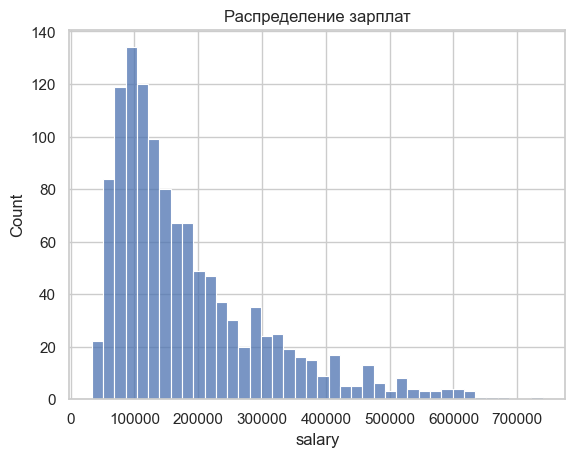

In [18]:
sns.histplot(data=df, x='salary', bins=40)
plt.title('Распределение зарплат');

**Вопрос:** в какую сторону вытянут хвост этого распределения и что это значит — каких зарплат много, а каких мало?

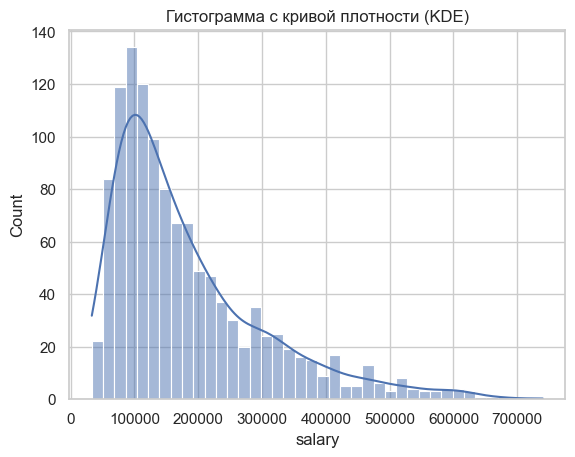

In [19]:
sns.histplot(data=df, x='salary', bins=40, kde=True)
plt.title('Гистограмма с кривой плотности (KDE)');

**Вывод:** плавная линия KDE подчёркивает форму — один пик слева и длинный правый хвост —
не отвлекая на «ступеньки» бинов. Отдельно кривую строит `sns.kdeplot()`.

### 4.3. Среднее и медиана на гистограмме

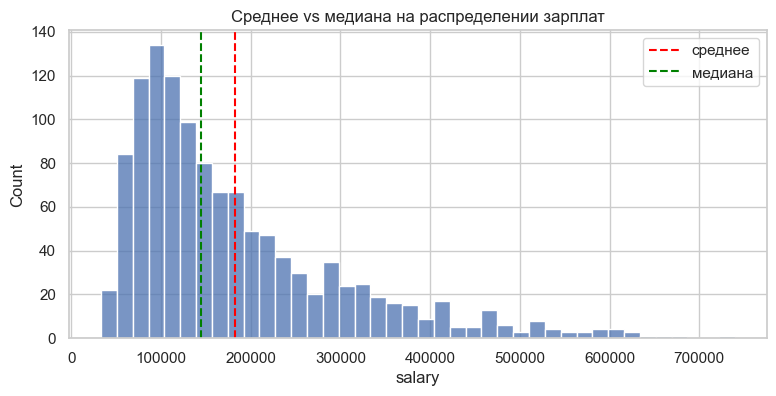

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='salary', bins=40, ax=ax)
ax.axvline(df['salary'].mean(),   color='red',   linestyle='--', label='среднее')
ax.axvline(df['salary'].median(), color='green', linestyle='--', label='медиана')
ax.set_title('Среднее vs медиана на распределении зарплат')
ax.legend();

**Вывод:** медиана (зелёная) стоит в «плотной» части, а среднее (красная) сдвинуто
**вправо**, к хвосту высоких зарплат. Глядя на гистограмму с этими линиями, аналитик за
секунду понимает: данные скошены, «типичную» зарплату лучше брать медианой.

---
## Часть 5. Форма распределения: асимметрия и эксцесс

Среднее и разброс не рассказывают о **форме**. Для неё есть два числа.

### 5.1. Асимметрия (Skewness)

**Асимметрия** измеряет **скошенность** — в какую сторону вытянут хвост. Формально это
усреднённое стандартизованное отклонение в **третьей** степени:

$$\text{skew} = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{\sigma}\right)^3$$

Куб сохраняет знак: значения справа от среднего дают плюс, слева — минус. Длиннее правый
хвост — сумма положительна.

```
skew ≈ 0   →  симметрично (хвосты одинаковы)
skew > 0   →  скос вправо (длинный правый хвост)
skew < 0   →  скос влево  (длинный левый хвост)
```

In [21]:
df['salary'].skew().round(2)

1.48

**Вопрос:** асимметрия получилась положительной (≈ 1.5). В какую сторону, судя по знаку, вытянут хвост распределения зарплат?




> **На практике:** если `skew` большая, среднее обманывает — берут медиану или **логарифмируют** признак (частый приём перед обучением модели на зарплатах, ценах, доходах).

### 5.2. Эксцесс (Kurtosis)

**Эксцесс** измеряет «тяжесть хвостов» и остроту пика относительно нормального. Та же идея,
но в **четвёртой** степени, с вычетом 3 (чтобы у нормального было 0):

$$\text{kurt} = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{\sigma}\right)^4 - 3$$

```
kurt ≈ 0   →  как у нормального
kurt > 0   →  острый пик и тяжёлые хвосты (много выбросов)
kurt < 0   →  плоская вершина, лёгкие хвосты
```

In [22]:
df['salary'].kurt().round(2)

2.12

**Вывод:** эксцесс заметно **выше** нуля: у зарплат тяжёлый правый хвост — крупные
зарплаты встречаются чаще, чем у «колокола».

> **На практике:** тяжёлые хвосты — это про **редкие, но крупные** события: топовые
> зарплаты, обвалы рынка, всплески нагрузки. Высокий эксцесс предупреждает: выбросы здесь не
> случайность, а свойство данных — их нельзя игнорировать в оценке риска.

| Показатель | Метод | Что описывает | Ориентир |
|---|---|---|---|
| Асимметрия | `.skew()` | скошенность, сторона хвоста | 0 — симметрично |
| Эксцесс | `.kurt()` | тяжесть хвостов, остроту пика | 0 — как у нормального |

---
## Часть 6. Виды распределений

Многие реальные величины следуют одному из типовых распределений. Узнавать их «в лицо»
полезно: форма подсказывает, каким числом описывать центр и чего ждать от данных.

> **На практике:** увидев форму, аналитик сразу понимает природу процесса. «Скос вправо,
> как у логнормального» → это похоже на зарплаты/цены → нужна медиана и, возможно, логарифм.
> «Быстрый спад, как у экспоненциального» → это интервалы между событиями → так моделируют
> нагрузку на сервер или поток клиентов.


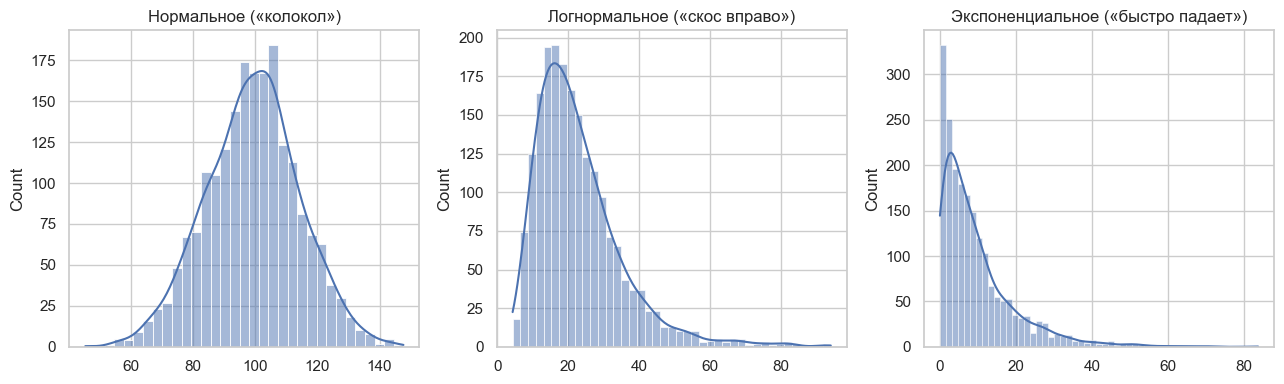

In [23]:
normal_sample = rng.normal(loc=100, scale=15, size=2000)  # нормальное
lognormal_sample = rng.lognormal(mean=3, sigma=0.5, size=2000)  # логнормальное
exp_sample = rng.exponential(scale=10, size=2000)  # экспоненциальное

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.histplot(normal_sample,    kde=True, ax=axes[0]); axes[0].set_title('Нормальное («колокол»)')
sns.histplot(lognormal_sample, kde=True, ax=axes[1]); axes[1].set_title('Логнормальное («скос вправо»)')
sns.histplot(exp_sample,       kde=True, ax=axes[2]); axes[2].set_title('Экспоненциальное («быстро падает»)')
plt.tight_layout();

**Вывод:** три характерные формы:

- **Нормальное** («колокол») — симметричное, значения кучкуются вокруг среднего,
  среднее ≈ медиана, асимметрия ≈ 0. Так распределены рост, погрешности измерений, IQ.
- **Логнормальное** («скос вправо») — длинный правый хвост, среднее > медианы. Так
  распределены **зарплаты**, доходы, цены — наш `salary` очень похож.
- **Экспоненциальное** («быстро падает») — максимум у нуля и резкий спад. Так распределены
  интервалы между редкими событиями (время до следующего увольнения, отказа техники).

Проверим формы числом — асимметрией:

In [24]:
for name, sample in [('нормальное', normal_sample),
                     ('логнормальное', lognormal_sample),
                     ('экспоненциальное', exp_sample)]:
    print(name, 'skew =', round(pd.Series(sample).skew(), 2))

нормальное skew = -0.05
логнормальное skew = 1.72
экспоненциальное skew = 2.12


**Вывод:** у нормального асимметрия около нуля, у логнормального и экспоненциального —
заметно положительная. Число подтверждает то, что видно глазом.

| Распределение | Форма | Признак | Примеры из жизни |
|---|---|---|---|
| Нормальное | симметричный «колокол» | среднее ≈ медиана, skew ≈ 0 | рост, ошибки измерений, IQ |
| Логнормальное | скос вправо | среднее > медианы, skew > 0 | зарплаты, доходы, цены |
| Экспоненциальное | пик у нуля, быстрый спад | резко падает вправо | время между событиями, отказы |

> **Как вы думаете.** У какого признака асимметрия больше — у `age` или у `salary`?

---
## Часть 7. Генеральная совокупность и выборка

Последнее важное различие — **о чём** мы вообще делаем выводы.

- **Генеральная совокупность** (*population*) — **все** объекты, которые нас интересуют: все
  работники отрасли, все избиратели страны.
- **Выборка** (*sample*) — **часть** совокупности, которую мы реально наблюдаем.

> **На практике:** измерить всю совокупность почти никогда нельзя — дорого, долго или
> невозможно. Поэтому берут **выборку** и по ней судят о целом. На этом стоят **опросы о
> зарплатах** (спросили 1500 человек — говорят про всю отрасль)

Нарисуем схему: светлые точки — вся совокупность, красные — случайно выбранная часть.

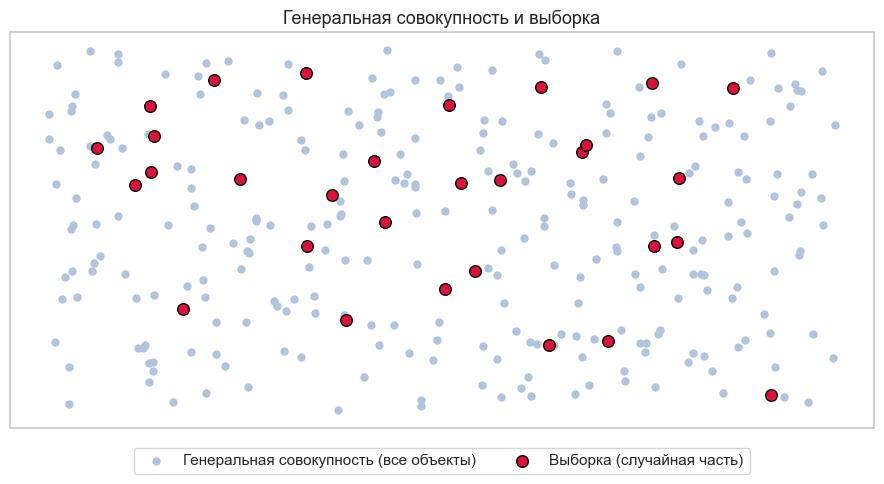

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

gen = np.random.default_rng(7)
pop = gen.uniform(0, 10, size=(300, 2))   # 300 объектов совокупности
idx = gen.choice(300, size=30, replace=False)   # 30 случайных — выборка
is_sample = np.zeros(300, dtype=bool)
is_sample[idx] = True

ax.scatter(pop[~is_sample, 0], pop[~is_sample, 1], s=25, color='lightsteelblue',
           label='Генеральная совокупность (все объекты)')
ax.scatter(pop[is_sample, 0], pop[is_sample, 1], s=70, color='crimson',
           edgecolor='black', label='Выборка (случайная часть)')

ax.set_title('Генеральная совокупность и выборка', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.03), ncol=2)
plt.tight_layout();

**Вывод:** выборка — это горстка красных точек, разбросанных по всей совокупности. Мы не
измеряем все 300 объектов, а по 30 случайным **оцениваем** характеристики целого.

### 7.1. Выборка из наших зарплат

Представим, что вся таблица — это **совокупность**, а мы можем «опросить» только часть.
Возьмём случайную выборку сотрудников методом `.sample()` и сравним среднюю зарплату выборки
со средней по всей таблице.

In [26]:
sample = df.sample(n=200, random_state=1)

print('Средняя зарплата по всей таблице:', round(df['salary'].mean()))
print('Средняя зарплата по выборке (200):', round(sample['salary'].mean()))

Средняя зарплата по всей таблице: 182815
Средняя зарплата по выборке (200): 197868


**Вопрос:** среднее по выборке из 200 сотрудников получилось близким к среднему всей таблицы, но не точь-в-точь. Почему возникает эта разница и как её уменьшить?

Посмотрим, как размер выборки влияет на точность оценки:

In [27]:
for k in [20, 100, 500, 1000]:
    m = df.sample(n=k, random_state=0)['salary'].mean()
    print('выборка', k, 'чел. → среднее', round(m))
print('вся совокупность → среднее', round(df['salary'].mean()))

выборка 20 чел. → среднее 209919
выборка 100 чел. → среднее 183980
выборка 500 чел. → среднее 185509
выборка 1000 чел. → среднее 183214
вся совокупность → среднее 182815


**Вывод:** чем больше выборка, тем ближе её среднее к истинному среднему совокупности.
Маленькая выборка может сильно ошибаться, большая — почти попадает в цель.

> **Термины:** характеристику выборки (например, выборочное среднее) называют **статистикой**,
> а истинную характеристику всей совокупности — **параметром**. Статистика — это оценка
> параметра. (Отсюда и деление на `n−1` из части 3: поправка делает выборочную оценку разброса
> точнее.)

---
## Итог занятия

Сегодня научились:
- различать **типы переменных** — количественные и качественные (номинальные и порядковые);
- считать **меры центра** — **`.mean()`**, **`.median()`**, **`.mode()`** — знать их
  **формулы** и считать руками, а по разнице «среднее vs медиана» распознавать скос;
- считать **меры разброса** — **`.var()`**, **`.std()`** (и разницу `n` vs `n−1`), квантили
  **`.quantile()`** и **`IQR`** — и снимать сводку через **`.describe()`**;
- визуализировать распределение **гистограммой** и **KDE** и наносить на них среднее и медиану;
- описывать **форму** числом — асимметрией **`.skew()`** и эксцессом **`.kurt()`**;
- узнавать **виды распределений** — нормальное, логнормальное, экспоненциальное;
- различать **генеральную совокупность** и **выборку** и понимать, что статистика выборки
  оценивает параметр совокупности.

**Главная мысль:** описательная статистика и визуализация распределений — первый шаг любого
анализа. Сначала мы **смотрим на форму** данных и **описываем её числами** (центр, разброс,
асимметрия), и только потом строим модели. Среднее без разброса и формы — это половина правды.